## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the research question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from scipy.integrate import solve_ivp
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ph03-projectile'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'models': '48fd2e6e706650fe2ee0c0ad80b6d794a546a1dec78dd9d370ac09db3cc3adbf', 'constants': '2533802a1a546c612d06ba2e931e4f32a418be854c75a5e9c327ff57d5b56126'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['models', 'constants']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def projectile_with_drag(mass,diameter,drag_coefficient,air_density,speed,angle_deg,gravity=9.80665,height_m=1.5):
    """Constant-density quadratic drag; terminate at a descending ground crossing."""
    if mass<=0 or diameter<=0 or drag_coefficient<0 or air_density<0 or speed<=0 or gravity<=0 or height_m<0:
        raise ValueError('Invalid projectile parameters')
    area=np.pi*(diameter/2)**2;factor=.5*air_density*drag_coefficient*area/mass
    angle=np.deg2rad(angle_deg);initial=[0,height_m,speed*np.cos(angle),speed*np.sin(angle)]
    def dynamics(t,state):
        x,z,vx,vz=state;velocity=np.hypot(vx,vz)
        return [vx,vz,-factor*velocity*vx,-gravity-factor*velocity*vz]
    def ground(t,state):return state[1]
    ground.direction=-1;ground.terminal=True
    solved=solve_ivp(dynamics,[0,60],initial,events=ground,dense_output=True,rtol=1e-9,atol=1e-11,max_step=.1)
    if not solved.success or len(solved.t_events[0])!=1:raise RuntimeError('Descending ground event not found')
    flight=float(solved.t_events[0][0]);t=np.linspace(0,flight,501);state=solved.sol(t)
    velocity=np.hypot(state[2],state[3]);energy=.5*mass*velocity**2+mass*gravity*state[1]
    drag_power=-.5*air_density*drag_coefficient*area*velocity**3
    return dict(t=t,state=state,flight_s=flight,range_m=float(state[0,-1]),energy_J=energy,drag_power_W=drag_power)

print("Method ready: projectile_with_drag")


Method ready: projectile_with_drag


### Data and model boundary

Pendulum, oscillator, projectile and heat trajectories are declared numerical models, not laboratory measurements. The gravitational acceleration is the conventional standard g0 when used. GW150914 uses actual frozen detector strain and published event timing; a filtered curve is not an independent significance or source-parameter analysis. Blackbody curves assume an ideal emitter.

## Steps

### 1. Specify the force model and ground event

Use constant air density and drag coefficient for a spherical cross-section. This omits wind, spin and speed-dependent coefficients. The event stops at the descending z=0 crossing; integration beyond impact would not describe flight.

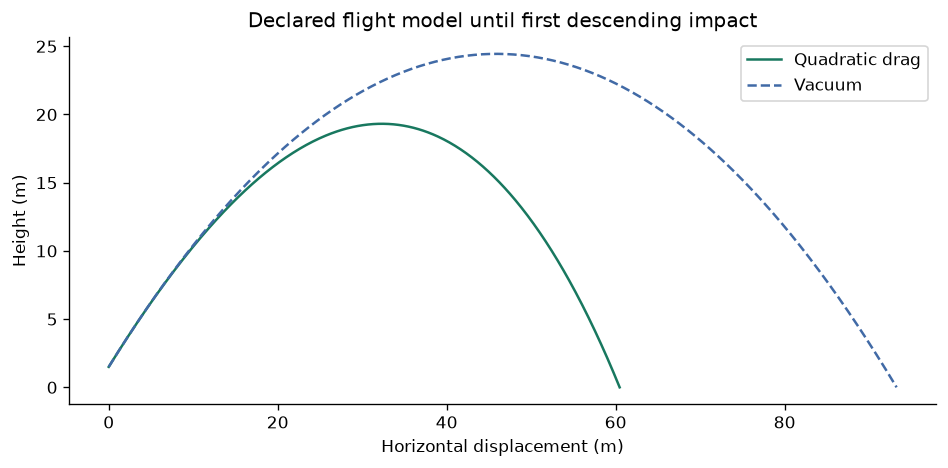

In [4]:
p=snapshot("models")["projectile"];gravity=snapshot("constants")["constants"]["g_0"]["value"]
arguments=dict(mass=p["mass_kg"],diameter=p["diameter_m"],air_density=p["air_density_kg_per_m3"],speed=p["speed_m_per_s"],angle_deg=p["angle_deg"],gravity=gravity,height_m=1.5)
drag=projectile_with_drag(**arguments,drag_coefficient=p["drag_coefficient"])
vacuum=projectile_with_drag(**arguments,drag_coefficient=0)
fig,ax=plt.subplots(figsize=(8,4));ax.plot(drag["state"][0],drag["state"][1],label="Quadratic drag")
ax.plot(vacuum["state"][0],vacuum["state"][1],"--",label="Vacuum")
ax.set(xlabel="Horizontal displacement (m)",ylabel="Height (m)",title="Declared flight model until first descending impact");ax.legend();plt.tight_layout();plt.show()


### 2. Inspect flight speed and timing

Speed is sqrt(vx²+vz²) in m/s. The two traces end at their own impact times; do not align them by pretending their durations are equal. Drag changes both the trajectory and the time of flight in this example.

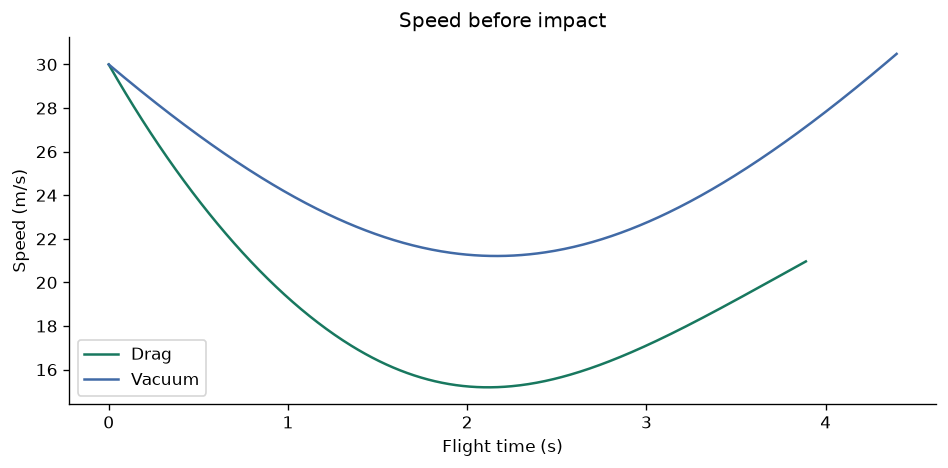

,model,flight_s,range_m
0,drag,3.889601,60.470905
1,vacuum,4.395881,93.250713


In [5]:
fig,ax=plt.subplots(figsize=(8,4))
for name,solution in [("Drag",drag),("Vacuum",vacuum)]:ax.plot(solution["t"],np.hypot(solution["state"][2],solution["state"][3]),label=name)
ax.set(xlabel="Flight time (s)",ylabel="Speed (m/s)",title="Speed before impact");ax.legend();plt.tight_layout();plt.show()
display(pd.DataFrame({"model":["drag","vacuum"],"flight_s":[drag["flight_s"],vacuum["flight_s"]],"range_m":[drag["range_m"],vacuum["range_m"]]}))


### 3. Reconcile drag work with mechanical-energy loss

Mechanical energy is ½mv²+mgz in joules. Drag power is negative and measured in watts. Integrating that power over time should recover the energy change to discretization accuracy. This is a conservation audit within the declared model, not an experimental drag measurement.

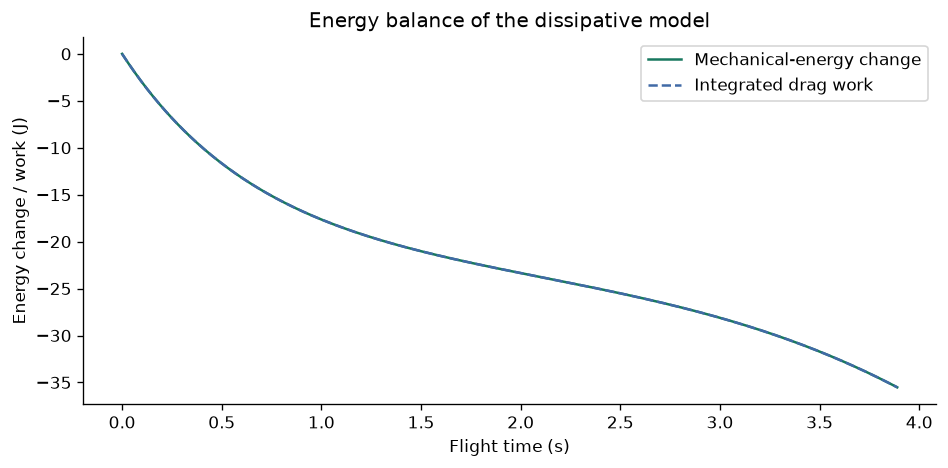

In [6]:
energy_change=drag["energy_J"]-drag["energy_J"][0]
widths=np.diff(drag["t"]);power=drag["drag_power_W"]
work=np.r_[0,np.cumsum(widths*(power[:-1]+power[1:])/2)]
fig,ax=plt.subplots(figsize=(8,4));ax.plot(drag["t"],energy_change,label="Mechanical-energy change")
ax.plot(drag["t"],work,"--",label="Integrated drag work")
ax.set(xlabel="Flight time (s)",ylabel="Energy change / work (J)",title="Energy balance of the dissipative model");ax.legend();plt.tight_layout();plt.show()


### 4. Check the vacuum limit and export

The zero-drag reference has an analytic flight time and range, including the nonzero launch height. Check the final ground height and energy balance before interpreting drag differences.

In [7]:
angle=np.deg2rad(arguments["angle_deg"]);vx=arguments["speed"]*np.cos(angle);vz=arguments["speed"]*np.sin(angle)
expected_time=(vz+np.sqrt(vz*vz+2*gravity*arguments["height_m"]))/gravity
assert np.isclose(vacuum["flight_s"],expected_time,rtol=1e-8)
assert np.isclose(vacuum["range_m"],vx*expected_time,rtol=1e-8)
assert abs(drag["state"][1,-1])<1e-8 and np.all(np.diff(drag["energy_J"])<=1e-5)
assert np.isclose(energy_change[-1],work[-1],rtol=.002)
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame({"time_s":drag["t"],"x_m":drag["state"][0],"z_m":drag["state"][1],"vx_m_per_s":drag["state"][2],"vz_m_per_s":drag["state"][3],"mechanical_energy_J":drag["energy_J"],"drag_power_W":power}).to_csv(OUTPUT_DIR/"drag-flight.csv",index=False)
print("Ground event, analytic vacuum and work checks passed; exports:",OUTPUT_DIR)


Ground event, analytic vacuum and work checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ph03-projectile


## Exercises and reference explanation

1. Explain the sign of drag power.
2. Why include launch height in the vacuum reference?

**Reference explanation.** Drag opposes velocity, so its dot product with velocity is nonpositive. Nonzero launch height changes flight time and range.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Using NumPy/SciPy/Matplotlib, compare initial angles 30, 45 and 60 degrees under the same declared drag model.

**Prompt 2**

> With the same packages, vary constant air density and export trajectories plus energy/work errors.

**Human acceptance.** Stop at descending ground events; zero-drag checks and dimensional energy balances pass.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [8]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://physics.nist.gov/cuu/Constants/',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [NIST CODATA physical constants](https://physics.nist.gov/cuu/Constants/Table/allascii.txt) — NIST public reference data; credit NIST/CODATA; retrieved 2026-10-09. SHA-256 `77fb90e66c40db3e6eb16630bc9c88e4c7c8beddbe5e71be406f2f26e3f67e67`.
  Preserve official ASCII table; extract seven explicitly named SI constants and their units.

- [IAPWS saturation reference release](https://iapws.org/public/documents/6dGkr/Supp-sat.pdf) — IAPWS SR1-86(1992): unrestricted publication allowed in all countries (cover page); retrieved 2026-10-09. SHA-256 `a10d38d73339b0713c86cfac88f9adcba137202167ccdfa1cd58238c438361d7`.
  Reference equations and numerical coefficients transcribed from release pages 2–3; pedagogical model values are not new experiments.

- [Authored numerical teaching model parameters](https://github.com/zhiluo20/vibeit/blob/main/cookbook-src/freeze_subject_data.py) — Original teaching parameters/code MIT; reference equation coefficients attributed to IAPWS SR1-86(1992); retrieved 2026-10-09. SHA-256 `4350c4305a83c772fa295a8be0ef86a247f2bfaae930a081720d3cd0c753abe0`.
  Declared parameters and seed; generated trajectories and calibration observations must be labelled simulated.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.